In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ishank2005/nyc-housing-prices-csv")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\kochu\.cache\kagglehub\datasets\ishank2005\nyc-housing-prices-csv\versions\1


<class 'pandas.DataFrame'>
RangeIndex: 34439 entries, 0 to 34438
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   borough_x     34439 non-null  int64  
 1   block         34439 non-null  int64  
 2   lot           34439 non-null  int64  
 3   sale_price    34439 non-null  int64  
 4   zip_code      34423 non-null  float64
 5   borough_y     34439 non-null  str    
 6   yearbuilt     34439 non-null  float64
 7   lotarea       34439 non-null  float64
 8   bldgarea      34439 non-null  float64
 9   resarea       34251 non-null  float64
 10  comarea       34251 non-null  float64
 11  unitsres      34439 non-null  float64
 12  unitstotal    34439 non-null  float64
 13  numfloors     34396 non-null  float64
 14  latitude      34433 non-null  float64
 15  longitude     34433 non-null  float64
 16  landuse       34436 non-null  float64
 17  bldgclass     34439 non-null  str    
 18  building_age  34439 non-null  float64

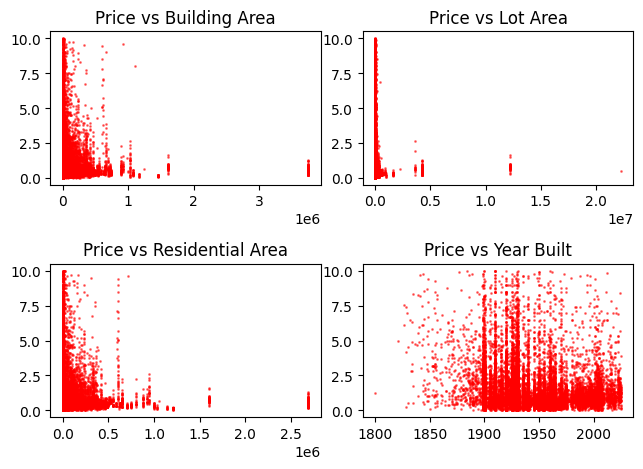

In [174]:
tset=pd.read_csv("nyc_housing_base.csv")

tset.info()
print("Null values in each column:\t")
tset.isnull().sum()
print("Total null values:\t")
tset.isnull().sum().sum()
tset=tset.drop_duplicates()
tset.describe()

tset=tset[tset["sale_price"]>0]
tset=tset.dropna()
tset["sale_price"]=tset["sale_price"]/1000000

x=tset[["bldgarea","lotarea","resarea","yearbuilt"]].values
y=tset["sale_price"].values

x = (x - x.mean(axis=0)) / x.std(axis=0)

fig,axis=plt.subplots(2,2)
gch={"color":"red","alpha":0.5,"s":1}
axis[0,0].scatter(tset["bldgarea"],tset["sale_price"],**gch)
axis[0,0].set_title("Price vs Building Area")

axis[0,1].scatter(tset["lotarea"],tset["sale_price"],**gch)
axis[0,1].set_title("Price vs Lot Area")

axis[1,0].scatter(tset["resarea"],tset["sale_price"],**gch)
axis[1,0].set_title("Price vs Residential Area")

axis[1,1].scatter(tset["yearbuilt"],tset["sale_price"],**gch)
axis[1,1].set_title("Price vs Year Built")

plt.tight_layout()
plt.show()

In [175]:
def cost_fun(x,y,w,b):
    m=len(y)
    cost_sum=0
    for i in range(m):
        f=np.dot(x[i],w)+b
        cost=(f-y[i])**2
        cost_sum+=cost
    tot_cost=(1/(2*m))*cost_sum
    return tot_cost

In [176]:
def grad(x,y,w,b):
    m=len(x)
    dc_dw=np.zeros_like(w)
    dc_db=0
    for i in range(m):
        f=np.dot(x[i],w)+b
        dc_dw+=(x[i])*(f-y[i])
        dc_db+=(f-y[i])
    dc_dw=dc_dw/m
    dc_db=dc_db/m
    return dc_dw,dc_db

In [177]:
def grad_descent(x,y,alpha,iteration):
    w=np.zeros(x.shape[1])
    b=0
    cost_history=[]
    for i in range(iteration):
        dc_dw,dc_db=grad(x,y,w,b)
        w=w-(alpha*dc_dw)
        b=b-(alpha*dc_db)
        costd=cost_fun(x,y,w,b)
        cost_history.append(costd)
        # if i % 100 == 0:
        #     print(cost_fun(x,y,w,b))
    plt.plot(cost_history)
    print(costd)
    plt.show()
    return w,b

0.868900033422928


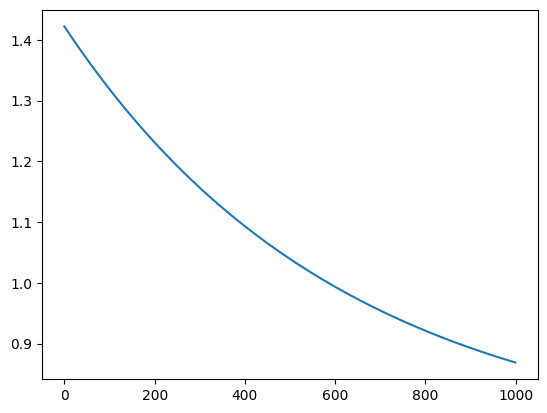

w= [-0.02841429 -0.00922518 -0.04078967 -0.08628676] b= 0.6407216323553891


In [178]:
alpha=8e-4
iteration=1000

final_w,final_b=grad_descent(x,y,alpha,iteration)

print("w=",final_w,"b=",final_b)

predicted y [0.77844539 0.77835687 0.71937513 0.91226626 0.71514884 0.64947737
 0.64947737 0.78284716 0.76888143 0.77586774]
original y [0.28  2.    3.4   4.    0.655 0.47  0.474 1.05  0.33  0.425]


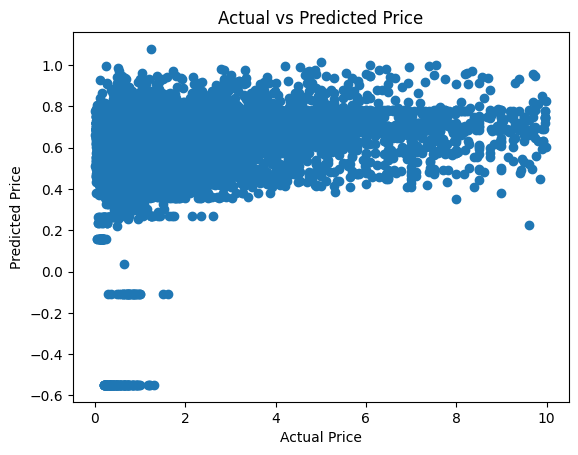

In [179]:
y_pred = np.dot(x, final_w) + final_b
print("predicted y",y_pred[:10])
print("original y",y[:10])

plt.scatter(y, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()